<a href="https://colab.research.google.com/github/maehwa0967/2026BDA/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 43.1 MB/s eta 0:00:00


In [ ]:
import koreanize_matplotlib

In [ ]:
##타이타닉
import pandas as pd

# GitHub의 Raw 파일 URL (웹에서 직접 읽기 위해 raw.githubusercontent.com 주소 사용)
df=pd.read_csv("https://raw.githubusercontent.com/ai7dnn/2026-1-BDA/main/titanic1309.csv",index_col=0)
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S


In [ ]:
df.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


In [ ]:
print(df['Name'].unique()) #
print(df['Sex'].unique())
print(df['SibSp'].unique()) #승선 중인 형제나 배우자의 수
print(df['Ticket'].unique()) # 티켓번호
print(df['Cabin'].unique()) # 방 번호
print(df['Embarked'].unique()) #승선한 항구 이름

['Braund, Mr. Owen Harris'
 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)'
 'Heikkinen, Miss. Laina' ... 'Saether, Mr. Simon Sivertsen'
 'Ware, Mr. Frederick' 'Peter, Master. Michael J']
['male' 'female']
[1 0 3 4 2 5 8]
['A/5 21171' 'PC 17599' 'STON/O2. 3101282' '113803' '373450' '330877'
 '17463' '349909' '347742' '237736' 'PP 9549' '113783' 'A/5. 2151'
 '347082' '350406' '248706' '382652' '244373' '345763' '2649' '239865'
 '248698' '330923' '113788' '347077' '2631' '19950' '330959' '349216'
 'PC 17601' 'PC 17569' '335677' 'C.A. 24579' 'PC 17604' '113789' '2677'
 'A./5. 2152' '345764' '2651' '7546' '11668' '349253' 'SC/Paris 2123'
 '330958' 'S.C./A.4. 23567' '370371' '14311' '2662' '349237' '3101295'
 'A/4. 39886' 'PC 17572' '2926' '113509' '19947' 'C.A. 31026' '2697'
 'C.A. 34651' 'CA 2144' '2669' '113572' '36973' '347088' 'PC 17605' '2661'
 'C.A. 29395' 'S.P. 3464' '3101281' '315151' 'C.A. 33111' 'S.O.C. 14879'
 '2680' '1601' '348123' '349208' '374746' '248738' '364516' '345

In [ ]:
print(df['Name'].nunique())

1307


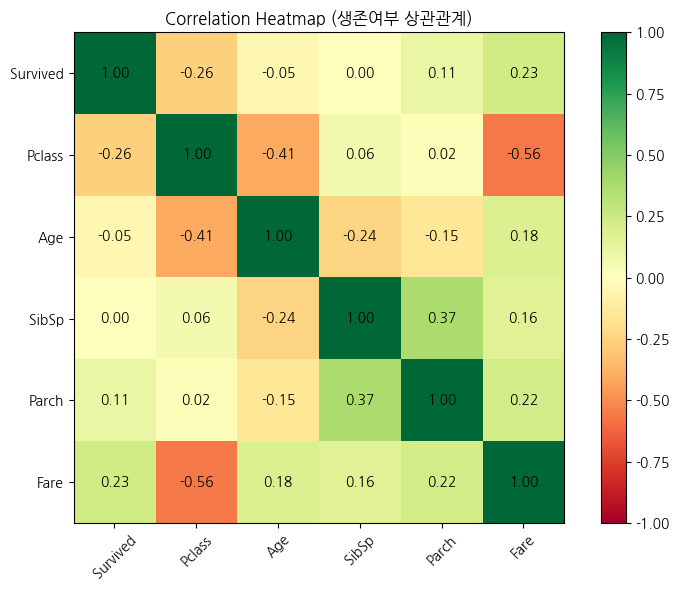

In [ ]:
#df.corr()
#0일수록 약하고 1,-1강하다

import pandas as pd
import matplotlib.pyplot as plt

# 데이터 불러오기


# 수치형 컬럼만 선택
cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df[cols].corr()

# 히트맵 그리기
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar()

# 축 라벨
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

# 각 칸에 숫자 표시
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f'{corr.values[i, j]:.2f}',
                 ha='center', va='center', fontsize=10)

plt.title('Correlation Heatmap (생존여부 상관관계)')
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=150)
plt.show()

변수상관계수해석Pclass-0.34등급 낮을수록(3등석) 사망 확률↑Fare+0.26운임 높을수록 생존 확률↑Age-0.08약한 음의 상관 (고령일수록 약간 불리)Parch+0.08거의 무관SibSp-0.04거의 무관

In [ ]:
df.describe(include='all')

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,1309.000000,1309.000000,1309,1309,1046.000000,1309.000000,1309.000000,1309,1308.000000,295,1307
unique,NaN,NaN,1307,2,NaN,NaN,NaN,929,NaN,186,3
top,NaN,NaN,"Kelly, Mr. James",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S
freq,NaN,NaN,2,843,NaN,NaN,NaN,11,NaN,6,914
mean,0.377387,2.294882,NaN,NaN,29.881138,0.498854,0.385027,NaN,33.295479,NaN,NaN
std,0.484918,0.837836,NaN,NaN,14.413493,1.041658,0.865560,NaN,51.758668,NaN,NaN
min,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,0.000000,2.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1.000000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 1 to 1309
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  1309 non-null   int64  
 1   Pclass    1309 non-null   int64  
 2   Name      1309 non-null   object 
 3   Sex       1309 non-null   object 
 4   Age       1046 non-null   float64
 5   SibSp     1309 non-null   int64  
 6   Parch     1309 non-null   int64  
 7   Ticket    1309 non-null   object 
 8   Fare      1308 non-null   float64
 9   Cabin     295 non-null    object 
 10  Embarked  1307 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 122.7+ KB


In [ ]:
df[['Survived']].sum(axis=0)

,0
Survived,494


In [ ]:
#블로그
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df.shape

(1309, 11)

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,263
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,1014


In [ ]:
#생존비율 확인
df["Survived"].value_counts()

,count
Survived,
0,815
1,494


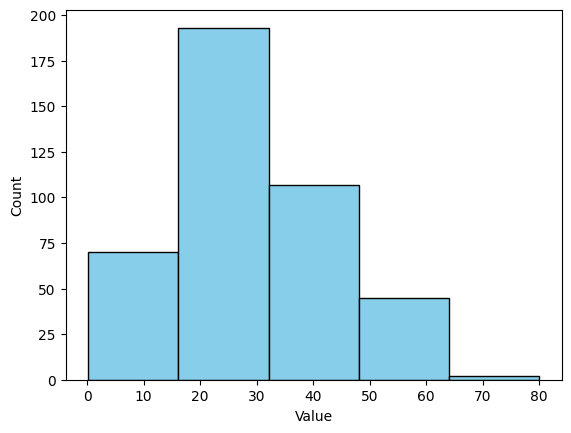

In [ ]:
import matplotlib.pyplot as plt

# 예시 데이터
survived = df[df['Survived'] == 1]['Age'].dropna()

# 히스토그램 그리기
plt.hist(survived, bins=5, color='skyblue', edgecolor='black')

# X축, Y축 이름 지정
plt.xlabel('Value')   # X축 라벨
plt.ylabel('Count')   # Y축 라벨

plt.show()


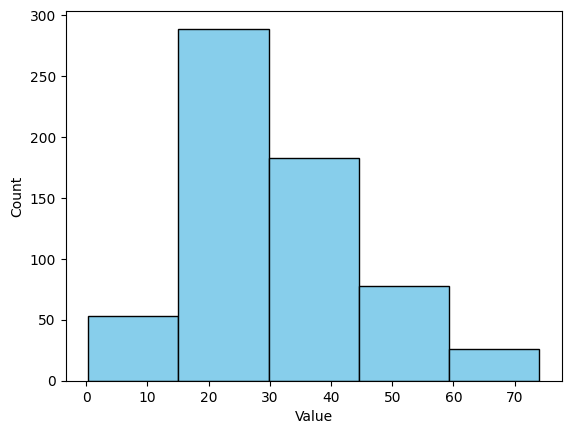

In [ ]:
import matplotlib.pyplot as plt

# 예시 데이터
dead     = df[df['Survived'] == 0]['Age'].dropna()

# 히스토그램 그리기
plt.hist(dead, bins=5, color='skyblue', edgecolor='black')

# X축, Y축 이름 지정
plt.xlabel('Value')   # X축 라벨
plt.ylabel('Count')   # Y축 라벨

plt.show()

<Axes: ylabel='count'>

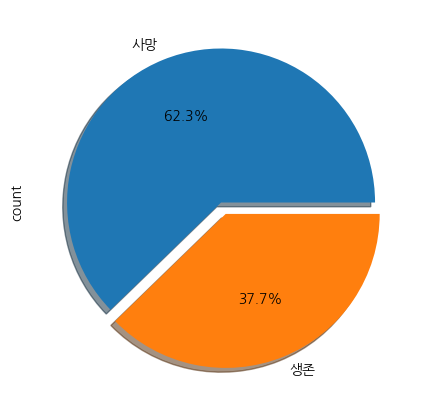

In [ ]:
plt.figure(figsize=(8,5))
labels=['사망','생존']
df['Survived'].value_counts().plot.pie(explode=[0,0.08],
                                     shadow=True,
                                     autopct='%1.1f%%',
                                     labels=labels)

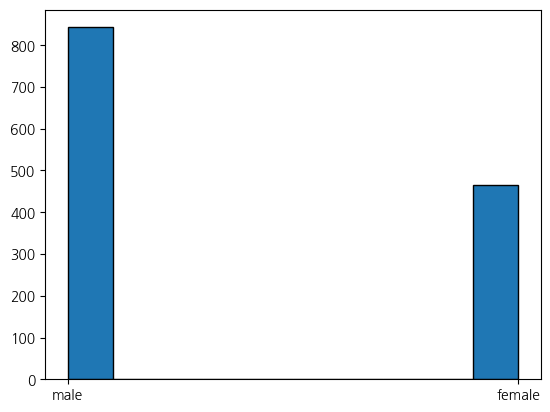

In [ ]:
plt.hist(df.Sex,edgecolor='black');

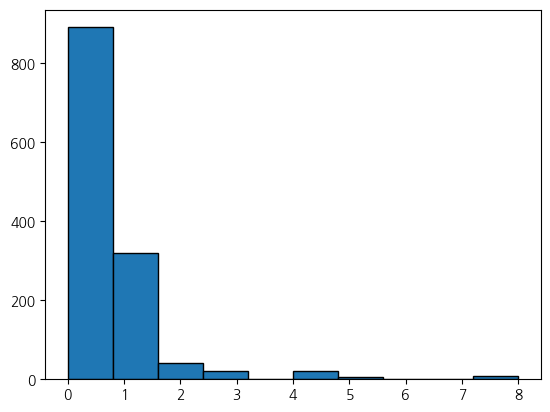

In [ ]:
plt.hist(df.SibSp,edgecolor='black');

## 항구 이미지
<img src="https://drive.google.com/uc?id=1GO3fZrNJgki6GTw_YrnzjkTZis90WRGl">

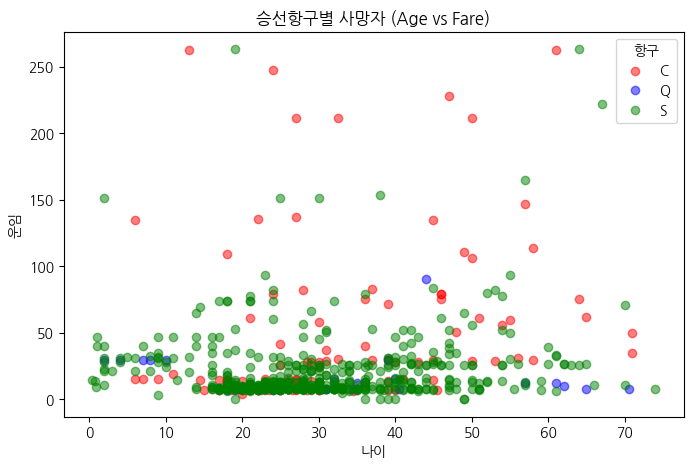

In [ ]:
# 사망자만
dead = df[df['Survived'] == 0]

# 항구별 색상
colors = {'C': 'red', 'Q': 'blue', 'S': 'green'}

# 산점도
plt.figure(figsize=(8, 5))

for port in ['C', 'Q', 'S']:
    data = dead[dead['Embarked'] == port]
    plt.scatter(data['Age'], data['Fare'],
                label=port,
                color=colors[port],
                alpha=0.5)

plt.title('승선항구별 사망자 (Age vs Fare)')
plt.xlabel('나이')
plt.ylabel('운임')
plt.legend(title='항구')

plt.show()

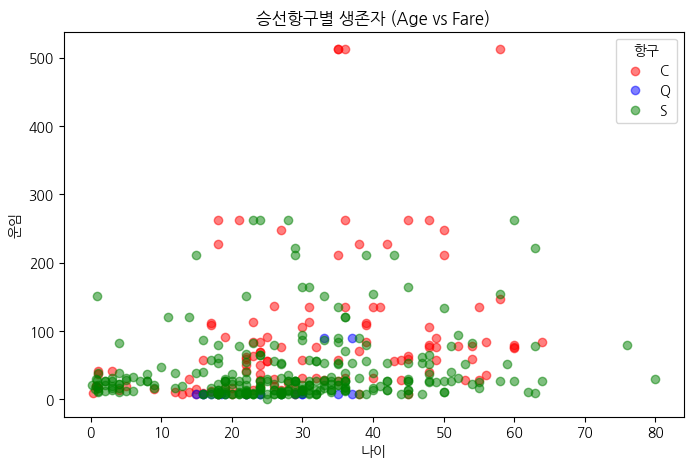

In [ ]:
import matplotlib.pyplot as plt

# 생존자만
survived = df[df['Survived'] == 1]

# 항구별 색상
colors = {'C': 'red', 'Q': 'blue', 'S': 'green'}

# 산점도
plt.figure(figsize=(8, 5))

for port in ['C', 'Q', 'S']:
    data = survived[survived['Embarked'] == port]
    plt.scatter(data['Age'], data['Fare'],
                label=port,
                color=colors[port],
                alpha=0.5)

plt.title('승선항구별 생존자 (Age vs Fare)')
plt.xlabel('나이')
plt.ylabel('운임')
plt.legend(title='항구')
plt.show()

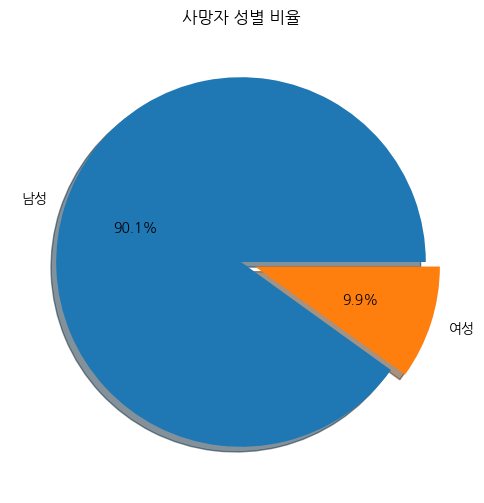

In [ ]:

# 사망자만
dead = df[df['Survived'] == 0]

# 성별 개수
sex_counts = dead['Sex'].value_counts()

# 파이차트
plt.figure(figsize=(6, 6))
plt.pie(sex_counts,
        labels=['남성', '여성'],
        autopct='%1.1f%%',
        explode=[0, 0.08],
        shadow=True)
plt.title('사망자 성별 비율')
plt.show()

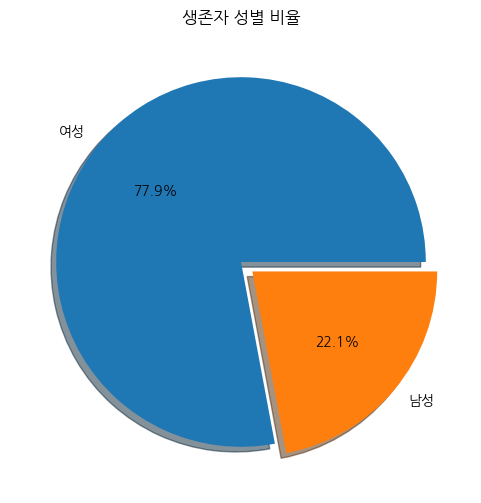

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# 생존자만
survived = df[df['Survived'] == 1]

# 성별 개수
sex_counts = survived['Sex'].value_counts()

# 파이차트
plt.figure(figsize=(6, 6))
plt.pie(sex_counts,
        labels=['여성', '남성'],
        autopct='%1.1f%%',
        explode=[0, 0.08],
        shadow=True)
plt.title('생존자 성별 비율')
plt.show()

In [ ]:
import seaborn as sns
import pandas as pd



# 2. 성별(Sex)과 생존여부(Survived)로 그룹화하고, 나이와 요금의 평균(mean) 및 중앙값(median) 계산
summary_df = df.groupby(['sex', 'survived'])[['age', 'fare']].agg(['mean', 'median'])

# 결과 확인
print(summary_df)

                       age              fare          
                      mean median       mean    median
sex    survived                                       
female 0         25.046875   24.5  23.024385  15.24580
       1         28.847716   28.0  51.938573  26.00000
male   0         31.618056   29.0  21.960993   9.41665
       1         27.276022   28.0  40.821484  26.28750


##감사합니다